# 1. Data Audit and Cleaning

In [1]:
# importing essential libraries
import numpy as np
import pandas as pd
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and Read dataset
data = pd.read_csv("laptop_prices.csv")

In [3]:
data.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [4]:
# Total number of rows and columns
data.shape

(1275, 23)

In [5]:
# Basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [6]:
# Checking for the missing values
data.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [7]:
# Checking any duplicate entries 
duplicates = data.duplicated().sum()
print(f'Number of duplicate rows : {duplicates}')

Number of duplicate rows : 0


In [8]:
# Total number of  unique values in each of the columns
data.nunique()

Company                  19
Product                 618
TypeName                  6
Inches                   18
Ram                       9
OS                        9
Weight                  171
Price_euros             791
Screen                    4
ScreenW                  13
ScreenH                  10
Touchscreen               2
IPSpanel                  2
RetinaDisplay             2
CPU_company               3
CPU_freq                 25
CPU_model                93
PrimaryStorage           13
SecondaryStorage          6
PrimaryStorageType        4
SecondaryStorageType      4
GPU_company               4
GPU_model               110
dtype: int64

In [9]:
# Basic Statistics of the dataset
data.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


### Observations
- Most laptops have 15-inch screens, making it the standard size.
- 8 GB RAM is the most common configuration.
- Average weight is around 2 kg, suitable for portability.
- Price range: majority between €600 – €1500, with a few premium models above €6000.
- Storage is mostly 256–512 GB, with some high-end models offering 1–2 TB.
- Screen resolutions vary from HD (1366×768) to 4K (3840×2160).
- CPUs generally run between 2.0–3.0 GHz, indicating mainstream performance levels

# 2. Exploratory Data Analysis(EDA)

In [10]:
# Importing essential libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Univariate Analysis

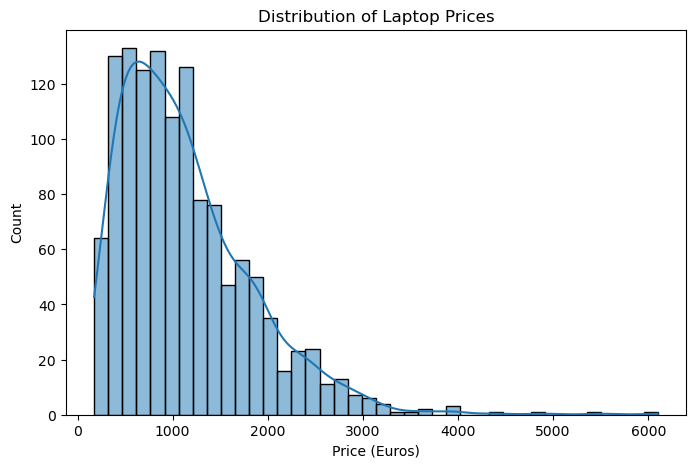

In [11]:
plt.figure(figsize = (8,5))
sns.histplot(data['Price_euros'], bins= 40, kde = True)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price (Euros)")
plt.ylabel("Count")
plt.show()

- Most laptops are priced between €600–1500, while a few premium models exceed €3000. These are valid outliers, representing high-end gaming or professional laptops.

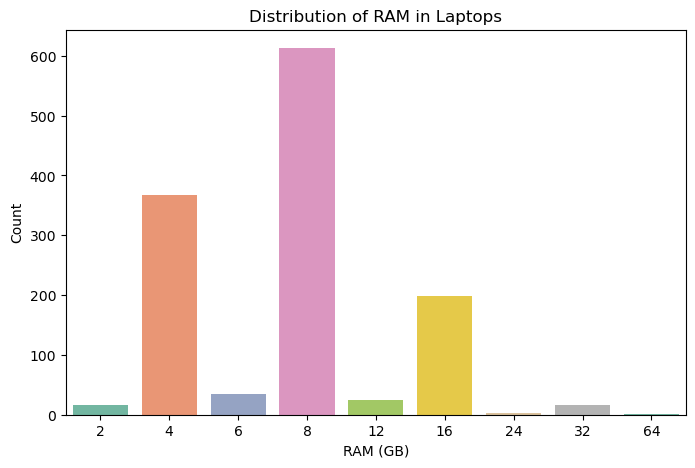

In [12]:
plt.figure(figsize = (8,5))
sns.countplot(x = "Ram", data = data, palette = "Set2")
plt.title("Distribution of RAM in Laptops")
plt.xlabel("RAM (GB)")
plt.ylabel("Count")
plt.show()


- 8GB is the most common RAM size, followed by 4GB and 16GB.
- Higher values like 32GB or 64GB appear rarely but are valid outliers, reflecting premium gaming and workstation laptops.

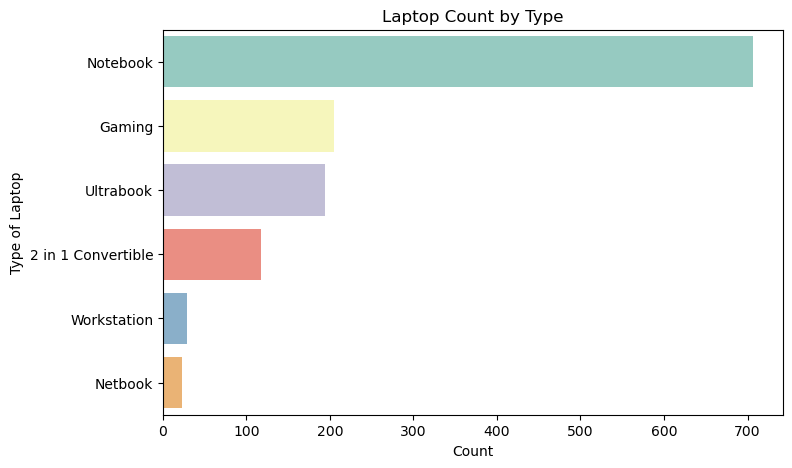

In [13]:
plt.figure(figsize = (8,5))
sns.countplot(y = "TypeName", data = data, order = data['TypeName'].value_counts().index, palette="Set3")
plt.title("Laptop Count by Type")
plt.xlabel("Count")
plt.ylabel("Type of Laptop")
plt.show()


- Notebooks dominate, followed by Gaming laptops and Ultrabooks.

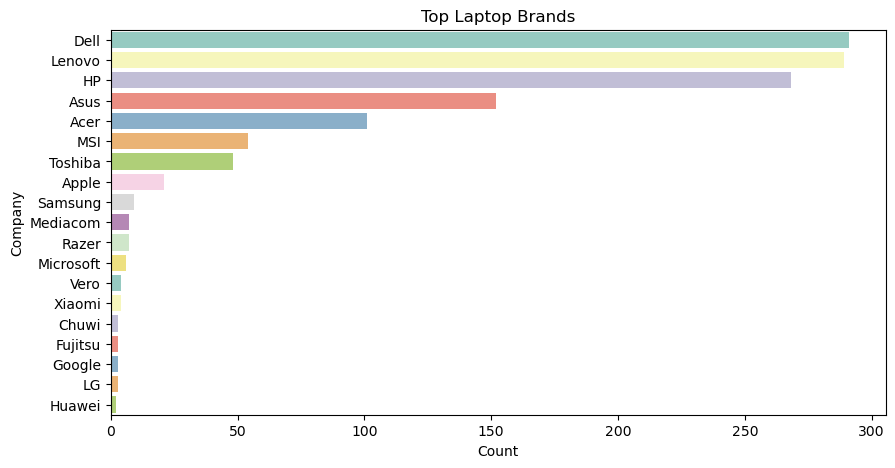

In [14]:
plt.figure(figsize = (10,5))
sns.countplot(y = "Company", data = data, order = data['Company'].value_counts().index, palette="Set3")
plt.title("Top Laptop Brands")
plt.xlabel("Count")
plt.ylabel("Company")
plt.show()


- Dell, Lenovo, and HP dominate the dataset, while Apple and Razer appear less frequently but represent premium offerings.

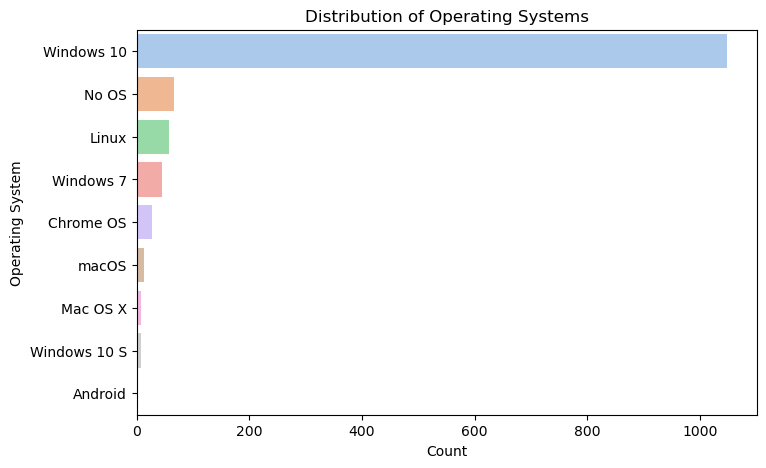

In [15]:
plt.figure(figsize = (8,5))
sns.countplot(y = "OS", data = data, order = data['OS'].value_counts().index, palette="pastel")
plt.title("Distribution of Operating Systems")
plt.xlabel("Count")
plt.ylabel("Operating System")
plt.show()


- The dataset is dominated by Windows 10 laptops, while other operating systems like Linux, No OS, and Windows 7 hold a minor share. Chrome OS and macOS variants appear rarely, reflecting niche usage.

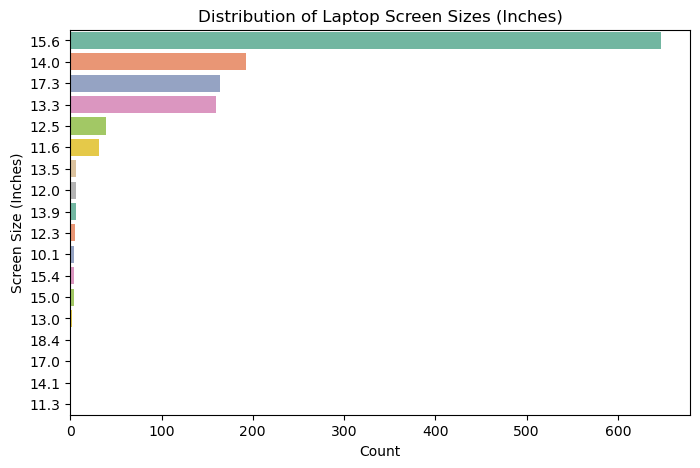

In [16]:
plt.figure(figsize = (8,5))
sns.countplot(data = data, y = 'Inches', order = data['Inches'].value_counts().index, palette = "Set2")
plt.title("Distribution of Laptop Screen Sizes (Inches)")
plt.xlabel("Count")
plt.ylabel("Screen Size (Inches)")
plt.show()


- The most common laptop screen size in the dataset is 15.6 inches, indicating it is the standard or most popular choice among users.
- It is followed by 14.0 inches and 17.3 inches, which are also relatively popular.

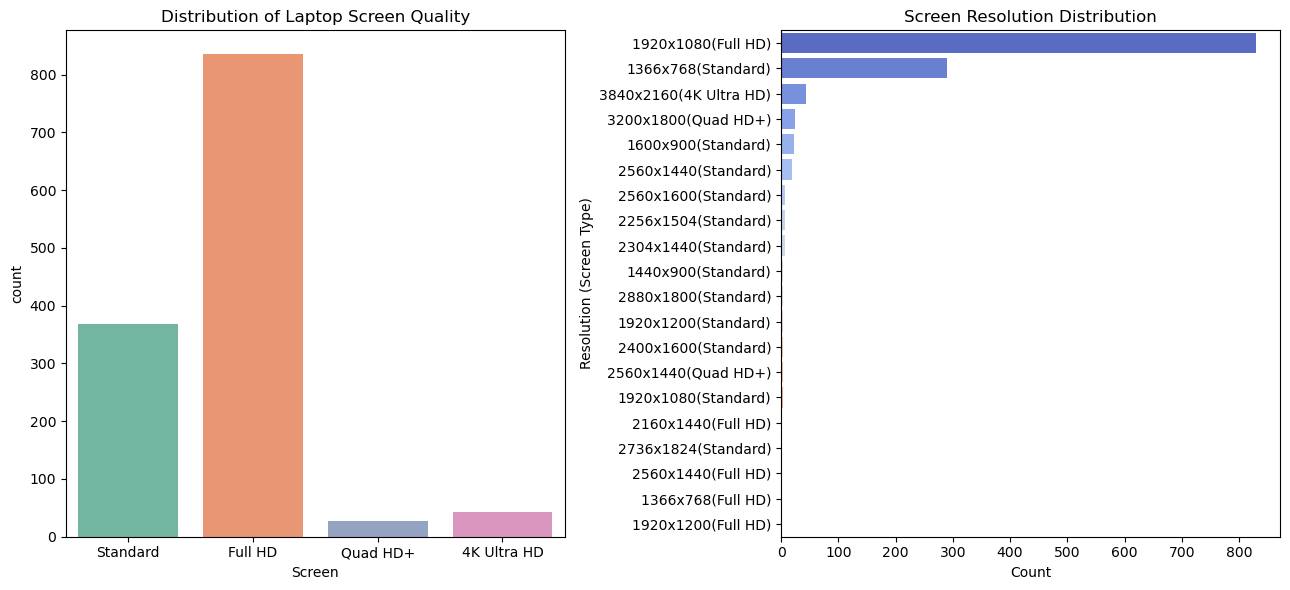

In [17]:
plt.figure(figsize = (13, 6))

# Laptop Screen Quality distribution
plt.subplot(1, 2, 1)
sns.countplot(data = data, x = "Screen", palette = "Set2")
plt.title("Distribution of Laptop Screen Quality")
plt.xlabel("Screen")
plt.ylabel("count")

data["Resolution"] = data["ScreenW"].astype(str) + "x" + data["ScreenH"].astype(str)
data["Resolution_Screen"] = data["Resolution"] + "("+ data["Screen"] +")"

# Screen Resolution distribution
plt.subplot(1, 2, 2)
sns.countplot(y = "Resolution_Screen", data = data, order = data['Resolution_Screen'].value_counts().index, palette = "coolwarm")
plt.title("Screen Resolution Distribution")
plt.xlabel("Count")
plt.ylabel("Resolution (Screen Type)")

plt.tight_layout()
plt.show()


- 1920×1080 (Full HD) is the most common resolution, while 1366×768 (Standard) appears often in budget laptops.
- Higher resolutions like 4K are rare, reflecting premium devices.

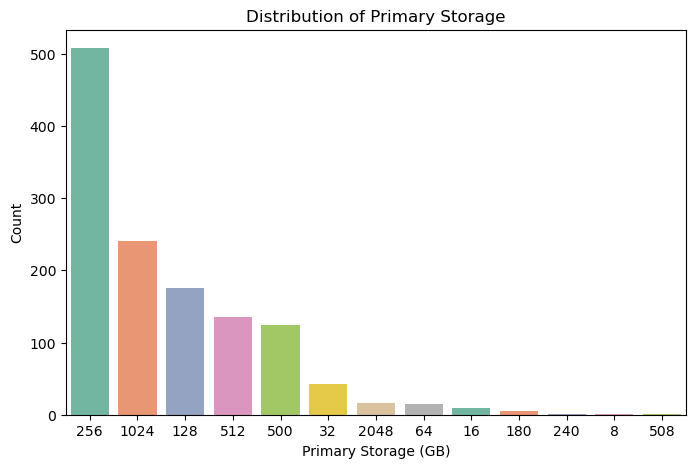

In [18]:
plt.figure(figsize = (8,5))
sns.countplot(x = "PrimaryStorage", data = data, order = data['PrimaryStorage'].value_counts().index, palette="Set2")
plt.title("Distribution of Primary Storage")
plt.xlabel("Primary Storage (GB)")
plt.ylabel("Count")
plt.show()


- Most laptops feature 256GB to 500GB primary storage, reflecting a balance between cost and everyday storage requirements.

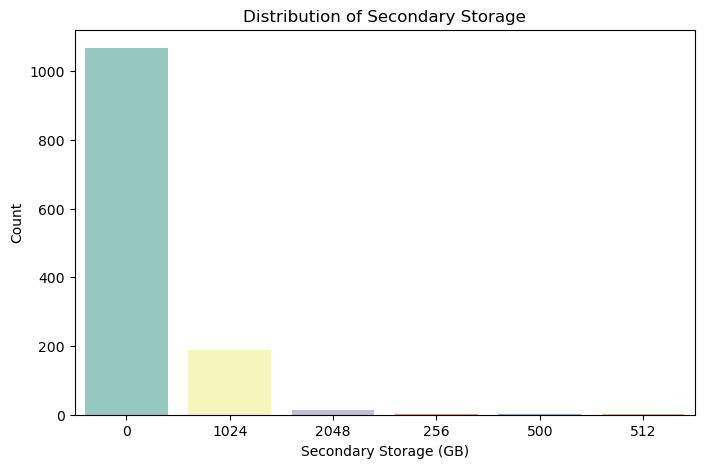

In [19]:
plt.figure(figsize = (8,5))
sns.countplot(x = "SecondaryStorage", data = data, order = data['SecondaryStorage'].value_counts().index, palette="Set3")
plt.title("Distribution of Secondary Storage")
plt.xlabel("Secondary Storage (GB)")
plt.ylabel("Count")
plt.show()
 

- Secondary storage is uncommon, and when available, 1024GB is the most typical capacity.

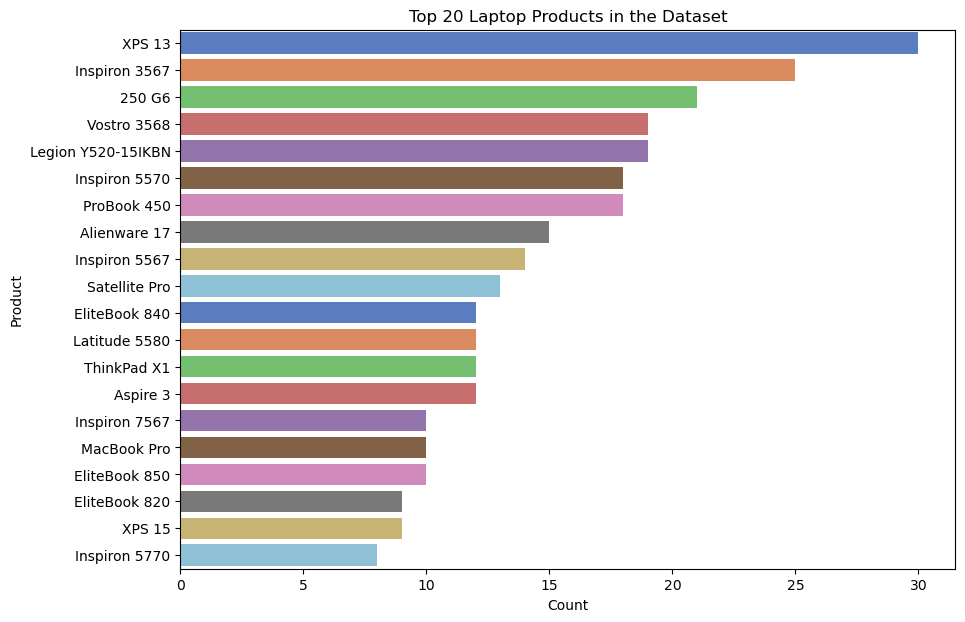

In [20]:
plt.figure(figsize = (10,7))
sns.countplot(y = "Product", data = data, order = data['Product'].value_counts().head(20).index, palette="muted")
plt.title("Top 20 Laptop Products in the Dataset")
plt.xlabel("Count")
plt.ylabel("Product")
plt.show()


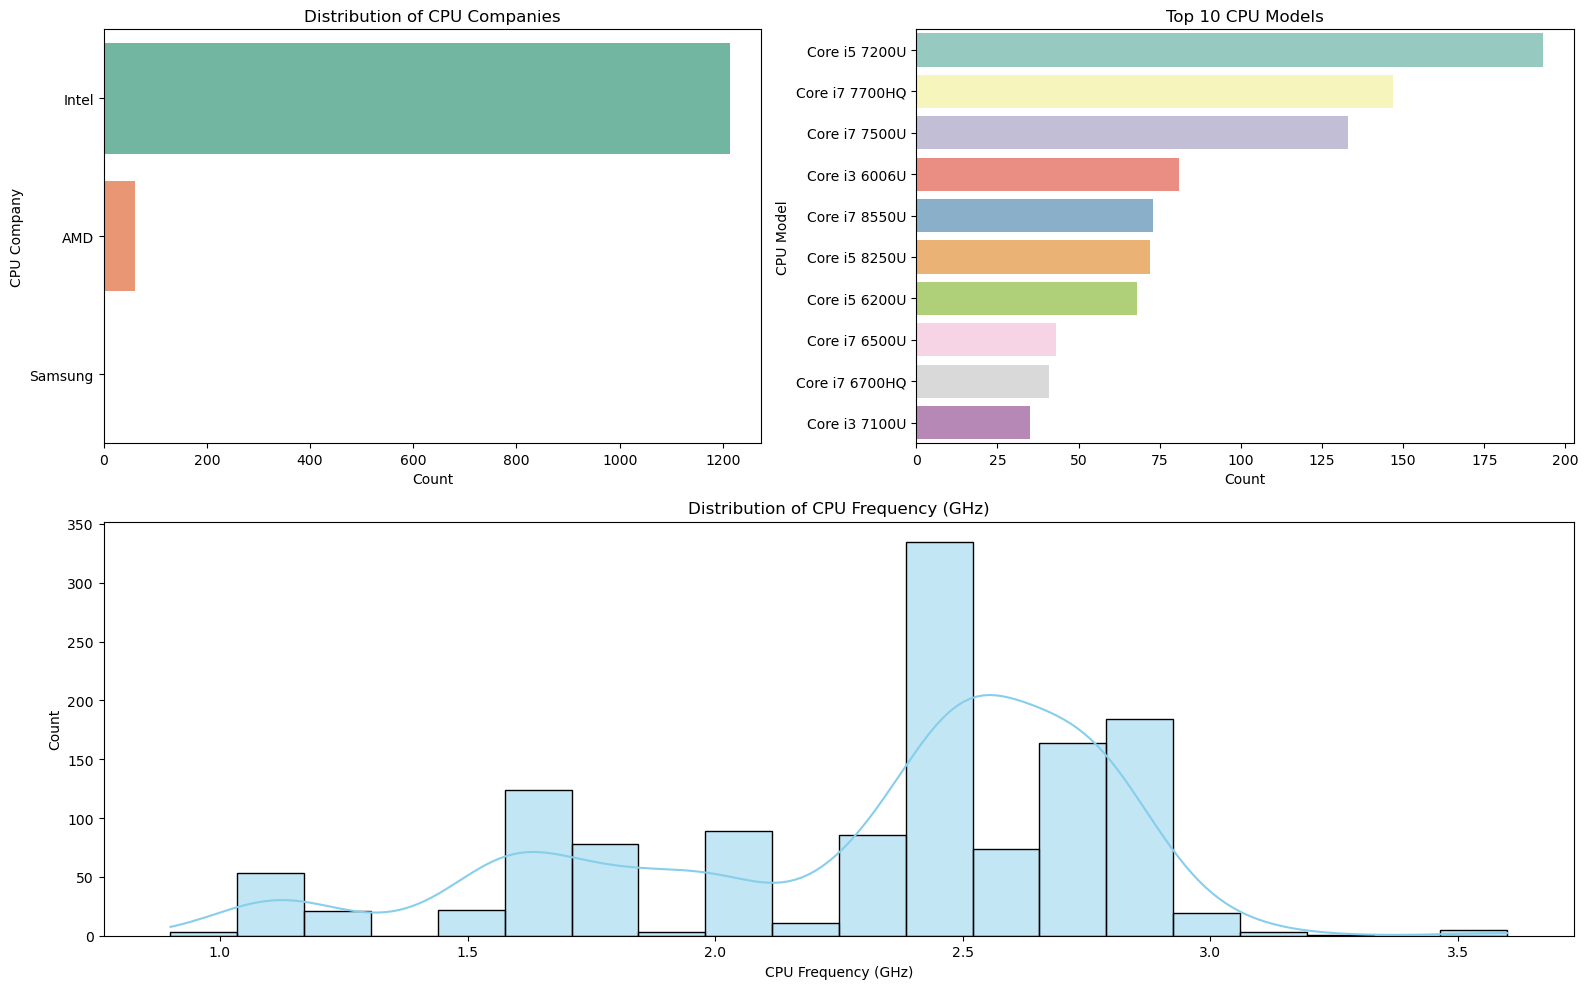

In [21]:
plt.figure(figsize=(16,10))

# CPU Company Distribution
plt.subplot(2,2,1)
sns.countplot(y = "CPU_company", data = data, order = data['CPU_company'].value_counts().index, palette = "Set2")
plt.title("Distribution of CPU Companies")
plt.xlabel("Count")
plt.ylabel("CPU Company")

# CPU Model Distribution
plt.subplot(2,2,2)
sns.countplot(y = "CPU_model", data = data, order = data['CPU_model'].value_counts().head(10).index, palette = "Set3") 
plt.title("Top 10 CPU Models")
plt.xlabel("Count")
plt.ylabel("CPU Model")

# CPU Frequency Distribution
plt.subplot(2,1,2)
sns.histplot(data["CPU_freq"], bins = 20, kde = True, color = "skyblue")
plt.title("Distribution of CPU Frequency (GHz)")
plt.xlabel("CPU Frequency (GHz)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


- Intel dominates, followed by AMD, others are rare.
- Core i5 and i7 are most common among the top models.
- Most CPUs run between 2.0–2.7 GHz, showing mid-range speeds are standard.

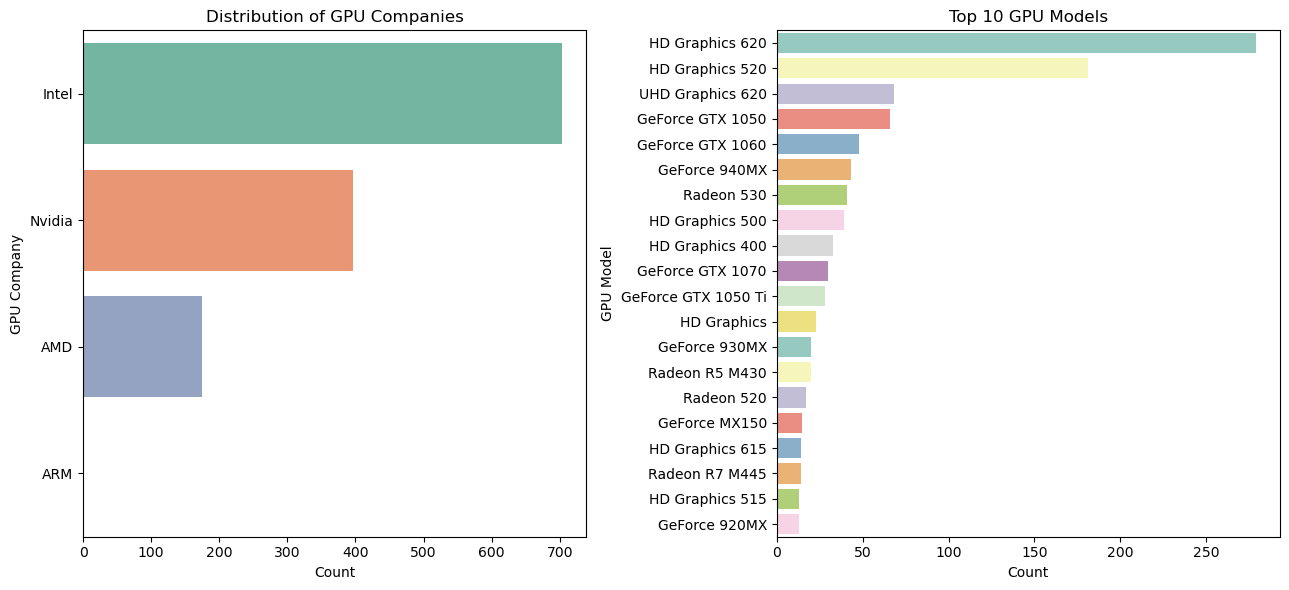

In [22]:
plt.figure(figsize=(13,6))

# GPU Company Distribution
plt.subplot(1,2,1)
sns.countplot(y = "GPU_company",  data = data, order = data['GPU_company'].value_counts().index, palette="Set2")
plt.title("Distribution of GPU Companies")
plt.xlabel("Count")
plt.ylabel("GPU Company")

# GPU Model Distribution (Top 10)
plt.subplot(1,2,2)
sns.countplot(y = "GPU_model",  data = data, order = data['GPU_model'].value_counts().head(20).index,  palette="Set3")
plt.title("Top 10 GPU Models")
plt.xlabel("Count")
plt.ylabel("GPU Model")

plt.tight_layout()
plt.show()


- Intel has the highest count of GPUs compared to other companies.
- Nvidia follows, with a lower count, while AMD has a much smaller share.
- HD Graphics 620 has the highest count among all models, followed by HD Graphics 520 and UHD Graphics 620.

## Bivariate Analysis

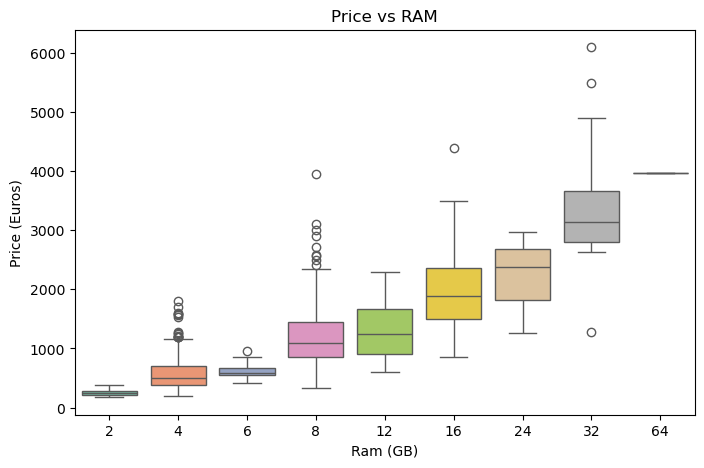

In [23]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = data, x = "Ram", y = "Price_euros", palette = "Set2")
plt.title("Price vs RAM")
plt.xlabel("Ram (GB)")
plt.ylabel("Price (Euros)")
plt.show()

- Higher RAM (32GB and 64GB) correlates with a substantial increase in laptop prices, often reaching over €4000.
- 2GB to 8GB RAM laptops are more affordable, ranging between €500-€2000.
- As RAM increases, the variability in price increases, indicating more premium and varied configurations.

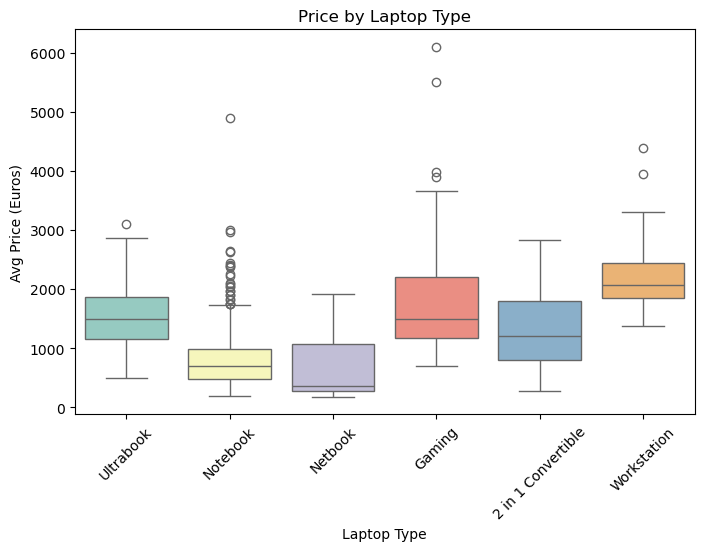

In [24]:
plt.figure(figsize = (8, 5))
sns.boxplot(data = data, x = "TypeName", y = "Price_euros", palette = "Set3")
plt.title("Price by Laptop Type")
plt.xlabel("Laptop Type")
plt.ylabel("Avg Price (Euros)")
plt.xticks(rotation = 45)
plt.show()


- Gaming and Workstation types show higher medians and wider price ranges (premium segment). Gaming laptops have the highest price range, often exceeding €4000
- Notebooks/Netbooks cluster at lower price points.
- Netbooks and Ultrabooks are more affordable, with average prices closer to €1000.

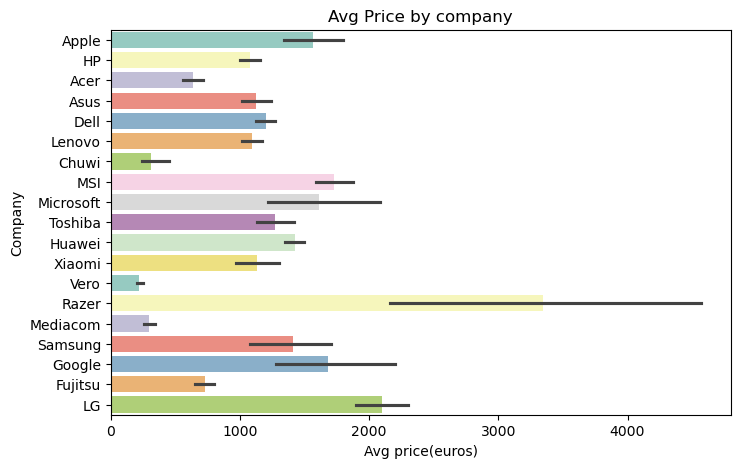

In [25]:
plt.figure(figsize = (8, 5))
sns.barplot(data = data, y = "Company", x = "Price_euros", palette = "Set3")
plt.title("Avg Price by company")
plt.xlabel("Avg price(euros)")
plt.ylabel("Company")
plt.show()


- Razer stands out with an exceptionally high average price.
- Apple and Microsoft also show higher average prices compared to others like HP, Acer, and Lenovo.
- Companies like Mediacom and Fujitsu have lower average prices

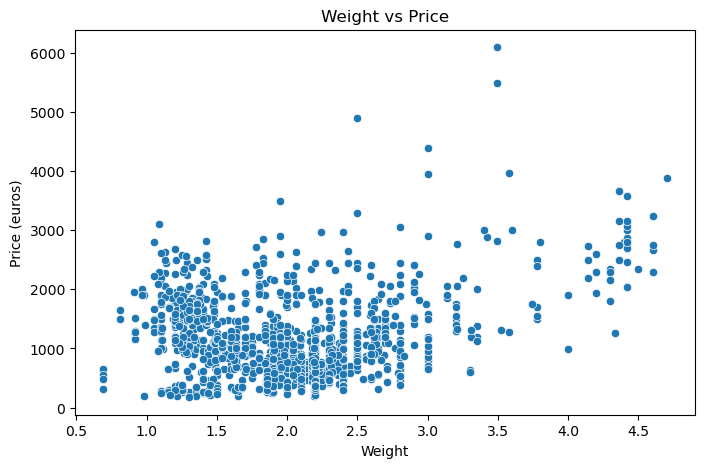

In [26]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = data, x = "Weight", y = "Price_euros", palette = "Set2")
plt.title("Weight vs Price")
plt.xlabel("Weight")
plt.ylabel("Price (euros)")
plt.show()

- Weight seems less important in price determination, with multiple weight categories showing laptops at varying price points.
- Heavier laptops do not show a clear positive or negative correlation with higher prices. However, there are some higher-priced models that are also heavier.
- Outliers at both low and high prices are evident, showing that factors other than weight (e.g., brand, specifications) influence the price.

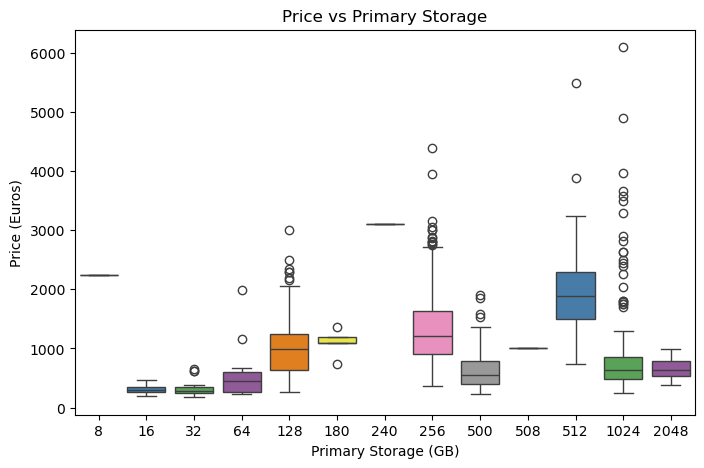

In [27]:
plt.figure(figsize = (8,5))
sns.boxplot(x = "PrimaryStorage", y = "Price_euros", data = data, palette="Set1")
plt.title("Price vs Primary Storage")
plt.xlabel("Primary Storage (GB)")
plt.ylabel("Price (Euros)")
plt.show()

- Laptops with higher primary storage (512GB or more) tend to have higher prices.
- 128GB storage is a threshold where prices start rising significantly.
- Laptops with 8GB or 16GB storage are on the lower price range, indicating entry-level models.
- Larger storage models (1024GB+) show outliers, suggesting that higher storage options can significantly increase the price.

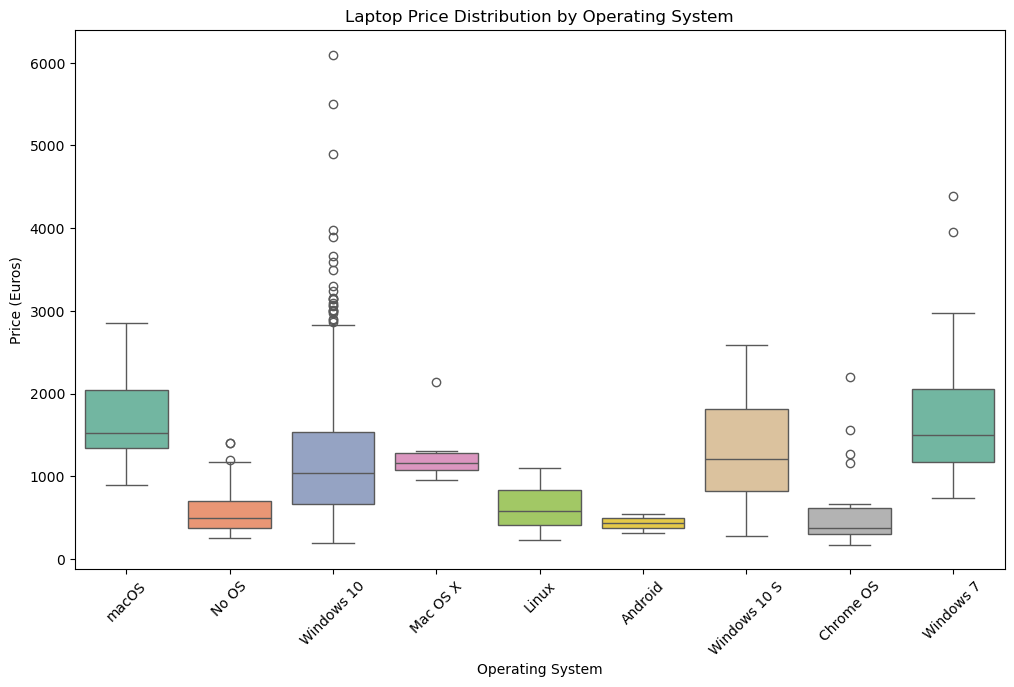

In [28]:
plt.figure(figsize = (12,7))
sns.boxplot(x = "OS", y = "Price_euros", data = data, palette = "Set2")

plt.title("Laptop Price Distribution by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Price (Euros)")
plt.xticks(rotation = 45)
plt.show()


- macOS laptops are premium, with high-end outliers.
- Windows 10 models show significant price variability, indicating a mix of entry-level to premium laptops.
- Laptops with No OS are much cheaper on average, indicating they are likely more basic models.
- Linux and Android laptops are typically more affordable compared to others.

## Multivariate Analysis

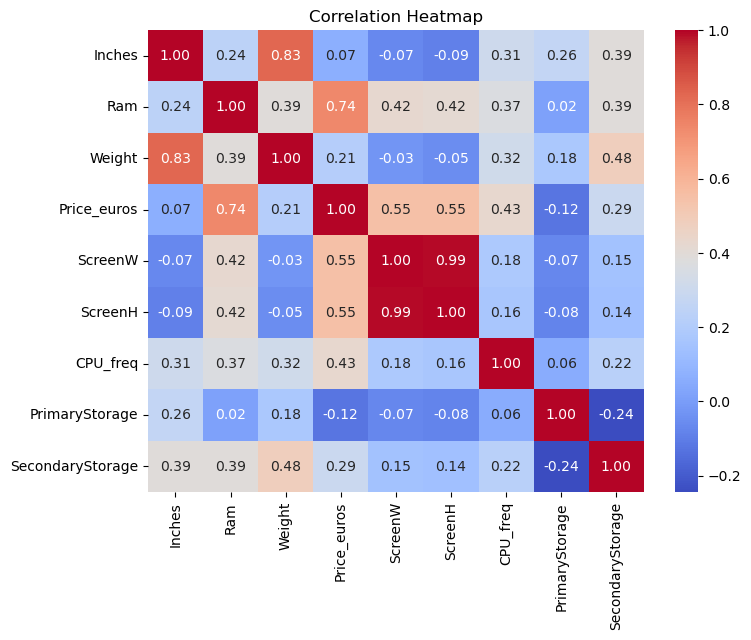

In [29]:
plt.figure(figsize = (8,6))
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



- Screen Width and Screen Height are almost perfectly correlated (≈0.99), meaning they provide nearly the same information.
- Inches and Weight have a very strong positive correlation (≈0.83), suggesting larger laptops tend to weigh more.
- RAM and Price show a strong positive correlation (≈0.74), indicating laptops with higher RAM are usually priced higher.
- ScreenW/ScreenH and Price also show moderate correlation (≈0.55), suggesting bigger screens are generally associated with higher prices.
- Secondary Storage and Weight have a moderate correlation (≈0.48), which may suggest heavier laptops often come with larger or additional storage.
- Overall, RAM, Screen Size, and Weight appear to be important drivers of laptop prices.

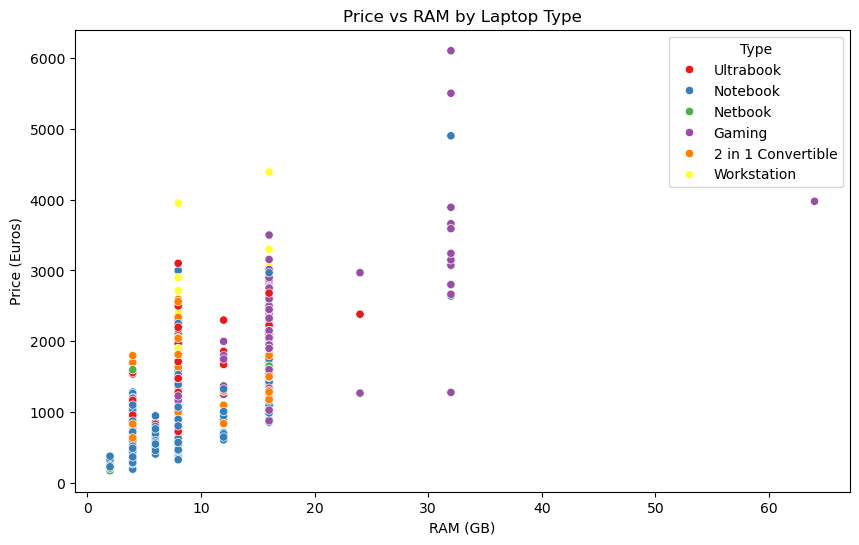

In [30]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = "Ram", y = "Price_euros", hue = "TypeName", data = data, palette="Set1")
plt.title("Price vs RAM by Laptop Type")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.legend(title="Type", bbox_to_anchor=(1,1))
plt.show()


- Workstations and gaming laptops tend to have the highest prices.
- Higher RAM (30 GB and above) is mainly found in gaming, workstation, and ultrabook categories.
- Gaming and workstation laptops dominate in the higher RAM and price regions, while ultrabooks and netbooks are more common in the lower price and RAM ranges.

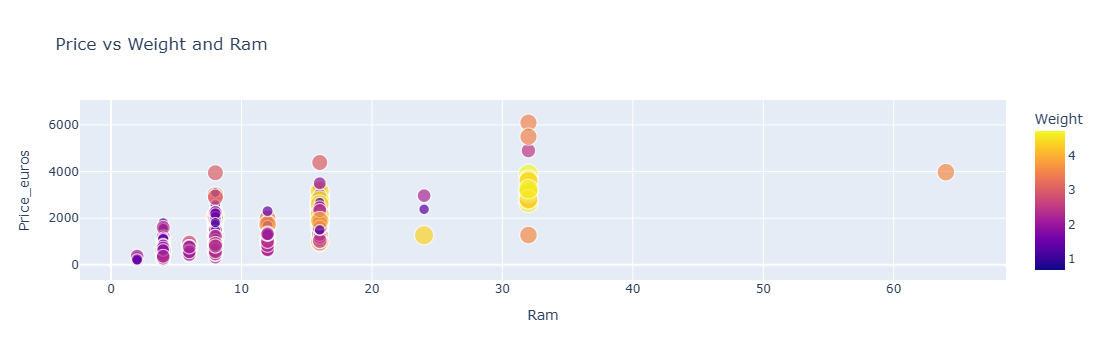

In [31]:
fig = px.scatter(data, x="Ram", y="Price_euros", color="Weight", size="Weight", title = "Price vs Weight and Ram")
fig.show()

- Higher RAM is associated with higher prices, with a significant number of high-price laptops having RAM above 30 GB.
- Laptops with higher RAM also tend to be heavier, especially in the higher price range.
- The color gradient shows that weight increases as RAM increases, particularly in high-end laptops.
- Some laptops with higher RAM (30-60 GB) have extremely high prices, with some reaching the 6000 euros range.

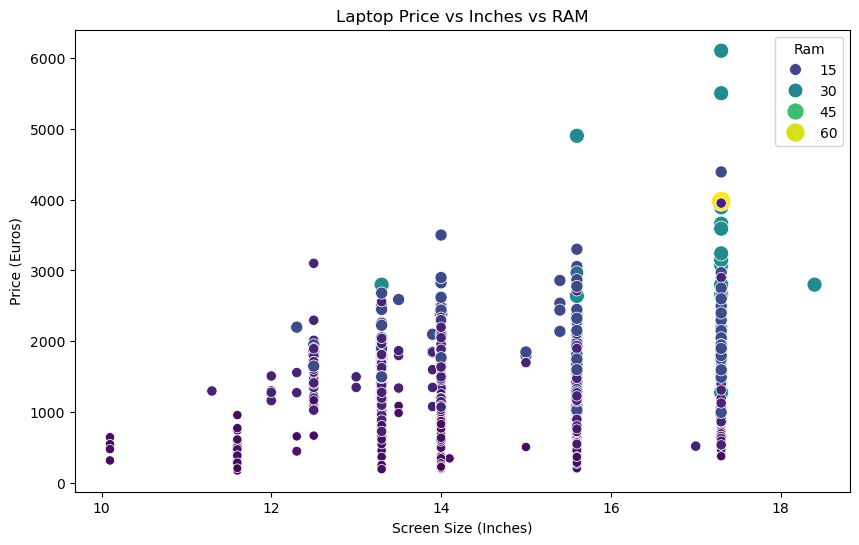

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="Inches", y="Price_euros", hue="Ram", palette="viridis", size="Ram", sizes=(40,200))
plt.title("Laptop Price vs Inches vs RAM")
plt.xlabel("Screen Size (Inches)")
plt.ylabel("Price (Euros)")
plt.show()


- Laptops with larger screens (15–18 inches) generally fall in higher price ranges, especially when paired with higher RAM.
- Smaller screen laptops (10–13 inches) mostly fall in the lower price range and usually come with lower RAM.
- Overall, Price increases with both Screen Size and RAM, but RAM appears to have the stronger influence on high-end pricing

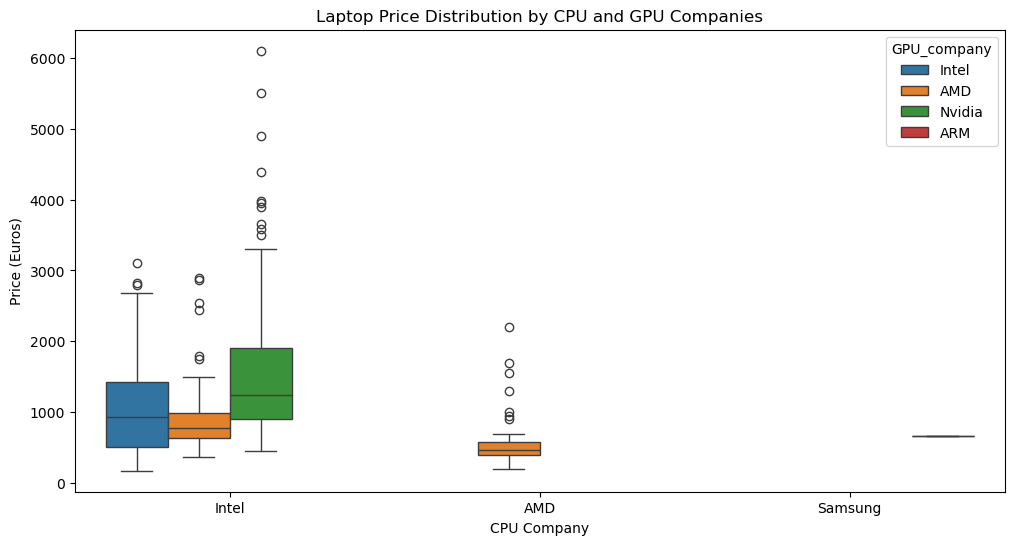

In [33]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x="CPU_company", y="Price_euros", hue="GPU_company")
plt.title("Laptop Price Distribution by CPU and GPU Companies")
plt.xlabel("CPU Company")
plt.ylabel("Price (Euros)")
plt.show()


- Intel CPUs with Nvidia GPUs generally belong to the higher price range, with many laptops priced above €2000.
- Intel CPUs with Intel GPU combinations have a wider spread, with both budget and premium laptops.
- AMD CPUs with AMD GPUs are generally found in the lower to mid-price range, making them more budget-friendly.
- Samsung CPU laptops appear only in a very narrow range at a fixed price, showing limited market presence.
- Nvidia GPUs are associated with higher prices compared to AMD or Intel GPUs, reflecting their premium positioning in gaming and performance laptops.

# 3. Feature Engineering

In [34]:
# making a copy of the original data
df = data.copy()

In [35]:
# Dropping the irrelevant columns
df = df.drop("Product", axis = 1)
df.head(2)

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,ScreenH,...,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Resolution,Resolution_Screen
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,1600,...,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,2560x1600,2560x1600(Standard)
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,900,...,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,1440x900,1440x900(Standard)


In [36]:
# Extracting essential features from the existing ones
df['PPI'] = (np.sqrt(df['ScreenW']**2 + df['ScreenH']**2) / df['Inches']).round(2)
df['Total_Storage'] = df['PrimaryStorage'] + df['SecondaryStorage']
df.head(3)

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,ScreenH,...,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Resolution,Resolution_Screen,PPI,Total_Storage
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,1600,...,128,0,SSD,No,Intel,Iris Plus Graphics 640,2560x1600,2560x1600(Standard),226.98,128
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,900,...,128,0,Flash Storage,No,Intel,HD Graphics 6000,1440x900,1440x900(Standard),127.68,128
2,HP,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,1080,...,256,0,SSD,No,Intel,HD Graphics 620,1920x1080,1920x1080(Full HD),141.21,256


In [37]:
print(df['CPU_model'].unique())

['Core i5' 'Core i5 7200U' 'Core i7' 'A9-Series 9420' 'Core i7 8550U'
 'Core i5 8250U' 'Core i3 6006U' 'Core M m3' 'Core i7 7500U'
 'Core i3 7100U' 'Atom x5-Z8350' 'Core i5 7300HQ' 'E-Series E2-9000e'
 'Core i7 8650U' 'Atom x5-Z8300' 'E-Series E2-6110' 'A6-Series 9220'
 'Celeron Dual Core N3350' 'Core i3 7130U' 'Core i7 7700HQ' 'Ryzen 1700'
 'Pentium Quad Core N4200' 'Atom x5-Z8550' 'Celeron Dual Core N3060'
 'FX 9830P' 'Core i7 7560U' 'E-Series 6110' 'Core i5 6200U' 'Core M 6Y75'
 'Core i5 7500U' 'Core i7 6920HQ' 'Core i5 7Y54' 'Core i7 7820HK'
 'Xeon E3-1505M V6' 'Core i7 6500U' 'E-Series 9000e'
 'A10-Series A10-9620P' 'A6-Series A6-9220' 'Core i7 6600U'
 'Celeron Dual Core 3205U' 'Core i7 7820HQ' 'A10-Series 9600P'
 'Core i7 7600U' 'A8-Series 7410' 'Celeron Dual Core 3855U'
 'Pentium Quad Core N3710' 'A12-Series 9720P' 'Core i5 7300U'
 'Celeron Quad Core N3450' 'Core i5 6440HQ' 'Core i7 6820HQ' 'Ryzen 1600'
 'Core i7 7Y75' 'Core i5 7440HQ' 'Core i7 7660U' 'Core M m3-7Y30'
 'Core i5 

In [38]:
# Define a function to classify CPU models into categories
def get_cpu_class(cpu):
    cpu = cpu.lower()  # make everything lowercase for easy matching
    
    if "i3" in cpu:
        return "i3"
    elif "i5" in cpu:
        return "i5"
    elif "i7" in cpu:
        return "i7"
    elif "i9" in cpu:
        return "i9"
    elif "ryzen" in cpu:
        return "Ryzen"
    elif "xeon" in cpu:
        return "Xeon"
    else:
        return "Other"

# Apply the function to create a new column
df["CPU_class"] = df["CPU_model"].apply(get_cpu_class)

df.head(3)

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,ScreenH,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Resolution,Resolution_Screen,PPI,Total_Storage,CPU_class
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,1600,...,0,SSD,No,Intel,Iris Plus Graphics 640,2560x1600,2560x1600(Standard),226.98,128,i5
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,900,...,0,Flash Storage,No,Intel,HD Graphics 6000,1440x900,1440x900(Standard),127.68,128,i5
2,HP,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,1080,...,0,SSD,No,Intel,HD Graphics 620,1920x1080,1920x1080(Full HD),141.21,256,i5


In [39]:
# Dropping irrelevant columns
df = df.drop('CPU_model', axis = 1)
df = df.drop(['ScreenW', 'ScreenH'], axis = 1)
df.head(3)

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,Touchscreen,IPSpanel,...,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model,Resolution,Resolution_Screen,PPI,Total_Storage,CPU_class
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,No,Yes,...,0,SSD,No,Intel,Iris Plus Graphics 640,2560x1600,2560x1600(Standard),226.98,128,i5
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,No,No,...,0,Flash Storage,No,Intel,HD Graphics 6000,1440x900,1440x900(Standard),127.68,128,i5
2,HP,Notebook,15.6,8,No OS,1.86,575.00,Full HD,No,No,...,0,SSD,No,Intel,HD Graphics 620,1920x1080,1920x1080(Full HD),141.21,256,i5


In [40]:
# Define a function to classify GPUs
def get_gpu_type(gpu):
    gpu = gpu.lower()
    if "intel" in gpu and "uhd" in gpu or "iris" in gpu:
        return "Integrated"
    elif "nvidia" in gpu or "radeon" in gpu or "rx" in gpu or "gtx" in gpu or "rtx" in gpu:
        return "Dedicated"
    else:
        return "Other"

df["GPU_Type"] = df["GPU_model"].apply(get_gpu_type)

In [41]:
df = df.drop("GPU_model", axis = 1)
df = df.drop("SecondaryStorage", axis = 1)
df = df.drop("SecondaryStorageType", axis = 1)
df.head(5)

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,Touchscreen,IPSpanel,...,CPU_freq,PrimaryStorage,PrimaryStorageType,GPU_company,Resolution,Resolution_Screen,PPI,Total_Storage,CPU_class,GPU_Type
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,No,Yes,...,2.3,128,SSD,Intel,2560x1600,2560x1600(Standard),226.98,128,i5,Integrated
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,No,No,...,1.8,128,Flash Storage,Intel,1440x900,1440x900(Standard),127.68,128,i5,Other
2,HP,Notebook,15.6,8,No OS,1.86,575.00,Full HD,No,No,...,2.5,256,SSD,Intel,1920x1080,1920x1080(Full HD),141.21,256,i5,Other
3,Apple,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,No,Yes,...,2.7,512,SSD,AMD,2880x1800,2880x1800(Standard),220.53,512,i7,Dedicated
4,Apple,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,No,Yes,...,3.1,256,SSD,Intel,2560x1600,2560x1600(Standard),226.98,256,i5,Integrated


In [42]:
df.shape

(1275, 22)

In [43]:
# All the columns in dataset
df.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight', 'Price_euros',
       'Screen', 'Touchscreen', 'IPSpanel', 'RetinaDisplay', 'CPU_company',
       'CPU_freq', 'PrimaryStorage', 'PrimaryStorageType', 'GPU_company',
       'Resolution', 'Resolution_Screen', 'PPI', 'Total_Storage', 'CPU_class',
       'GPU_Type'],
      dtype='object')

In [44]:
df = df.drop(['Resolution_Screen', 'Resolution'], axis = 1)
df.shape

(1275, 20)

In [45]:
df["Screen"].unique()

array(['Standard', 'Full HD', 'Quad HD+', '4K Ultra HD'], dtype=object)

In [46]:
# Make a copy of the original data to work on encoding/scaling without modifying the original data
df_encoded = df.copy()

In [47]:
# Converting Categorical Columns to Numeric using label encoding as they are ordinal columns
df_encoded["Touchscreen"] = df_encoded["Touchscreen"].map({'No':0, 'Yes':1})
df_encoded["IPSpanel"] = df_encoded["IPSpanel"].map({'No':0, 'Yes':1})
df_encoded["RetinaDisplay"] = df_encoded["RetinaDisplay"].map({'No':0, 'Yes':1})
df_encoded["CPU_class"] = df_encoded["CPU_class"].map({'i3':0, 'i5':1, 'i7':2, 'i9':3, 'Ryzen':4, 'Xeon':5, 'Other':6})
df_encoded["Screen"] = df_encoded["Screen"].map({'Standard':0, 'Full HD':1, 'Quad HD+':2, '4K Ultra HD':3})

In [48]:
df_encoded.head()

,Company,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_company,CPU_freq,PrimaryStorage,PrimaryStorageType,GPU_company,PPI,Total_Storage,CPU_class,GPU_Type
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,0,0,1,1,Intel,2.3,128,SSD,Intel,226.98,128,1,Integrated
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,0,0,0,0,Intel,1.8,128,Flash Storage,Intel,127.68,128,1,Other
2,HP,Notebook,15.6,8,No OS,1.86,575.00,1,0,0,0,Intel,2.5,256,SSD,Intel,141.21,256,1,Other
3,Apple,Ultrabook,15.4,16,macOS,1.83,2537.45,0,0,1,1,Intel,2.7,512,SSD,AMD,220.53,512,2,Dedicated
4,Apple,Ultrabook,13.3,8,macOS,1.37,1803.60,0,0,1,1,Intel,3.1,256,SSD,Intel,226.98,256,1,Integrated


In [49]:
# Converting the remaining categorical columns to Numeric using one hot encoding as they are Nominal columns
nominal_cols = ['Company', 'TypeName', 'OS', 'CPU_company', 'PrimaryStorageType', 'GPU_company', 'GPU_Type']
df_encoded = pd.get_dummies(df_encoded, columns = nominal_cols, drop_first = True, dtype = int)

In [50]:
df_encoded.head()

,Inches,Ram,Weight,Price_euros,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_freq,PrimaryStorage,...,CPU_company_Intel,CPU_company_Samsung,PrimaryStorageType_HDD,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia,GPU_Type_Integrated,GPU_Type_Other
0,13.3,8,1.37,1339.69,0,0,1,1,2.3,128,...,1,0,0,0,1,0,1,0,1,0
1,13.3,8,1.34,898.94,0,0,0,0,1.8,128,...,1,0,0,0,0,0,1,0,0,1
2,15.6,8,1.86,575.00,1,0,0,0,2.5,256,...,1,0,0,0,1,0,1,0,0,1
3,15.4,16,1.83,2537.45,0,0,1,1,2.7,512,...,1,0,0,0,1,0,0,0,0,0
4,13.3,8,1.37,1803.60,0,0,1,1,3.1,256,...,1,0,0,0,1,0,1,0,1,0


In [51]:
df_encoded.columns

Index(['Inches', 'Ram', 'Weight', 'Price_euros', 'Screen', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_freq', 'PrimaryStorage', 'PPI',
       'Total_Storage', 'CPU_class', 'Company_Apple', 'Company_Asus',
       'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google',
       'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo',
       'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'OS_Chrome OS',
       'OS_Linux', 'OS_Mac OS X', 'OS_No OS', 'OS_Windows 10',
       'OS_Windows 10 S', 'OS_Windows 7', 'OS_macOS', 'CPU_company_Intel',
       'CPU_company_Samsung', 'PrimaryStorageType_HDD',
       'PrimaryStorageType_Hybrid', 'PrimaryStorageType_SSD',
       'GPU_company_ARM', 'GPU_company_Intel', 'GPU_company_Nvidia',
       'GPU_Typ

In [52]:
# Import scaling classes to standardize or normalize numeric features
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [53]:
# Scaling the numeric features
numeric_cols = ['Inches', 'Ram', 'Weight', 'CPU_freq', 'Total_Storage', 'PPI', 'PrimaryStorage']
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [54]:
df_encoded.head(10)

,Inches,Ram,Weight,Price_euros,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_freq,PrimaryStorage,...,CPU_company_Intel,CPU_company_Samsung,PrimaryStorageType_HDD,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia,GPU_Type_Integrated,GPU_Type_Other
0,-1.205746,-0.086499,-1.002380,1339.69,0,0,1,1,-0.005918,-0.866236,...,1,0,0,0,1,0,1,0,1,0
1,-1.205746,-0.086499,-1.047227,898.94,0,0,0,0,-0.998674,-0.866236,...,1,0,0,0,0,0,1,0,0,1
2,0.403873,-0.086499,-0.269871,575.00,1,0,0,0,0.391185,-0.515929,...,1,0,0,0,1,0,1,0,0,1
3,0.263906,1.483418,-0.314718,2537.45,0,0,1,1,0.788288,0.184684,...,1,0,0,0,1,0,0,0,0,0
4,-1.205746,-0.086499,-1.002380,1803.60,0,0,1,1,1.582493,-0.515929,...,1,0,0,0,1,0,1,0,1,0
5,0.403873,-0.871458,0.088909,400.00,0,0,0,0,1.383942,0.151842,...,0,0,1,0,0,0,0,0,0,0
6,0.263906,1.483418,-0.000786,2139.97,0,0,1,1,-0.204469,-0.515929,...,1,0,0,0,0,0,1,0,1,0
7,-1.205746,-0.086499,-1.047227,1158.70,0,0,0,0,-0.998674,-0.515929,...,1,0,0,0,0,0,1,0,0,1
8,-0.715862,1.483418,-1.107024,1495.00,1,0,0,0,-0.998674,0.184684,...,1,0,0,0,1,0,0,1,0,1
9,-0.715862,-0.086499,-0.658549,770.00,1,0,1,0,-1.395777,-0.515929,...,1,0,0,0,1,0,1,0,0,1


In [55]:
# Check the data types of all columns to ensure they are correct and ready for model building
print(df_encoded.dtypes)

Inches                       float64
Ram                          float64
Weight                       float64
Price_euros                  float64
Screen                         int64
Touchscreen                    int64
IPSpanel                       int64
RetinaDisplay                  int64
CPU_freq                     float64
PrimaryStorage               float64
PPI                          float64
Total_Storage                float64
CPU_class                      int64
Company_Apple                  int64
Company_Asus                   int64
Company_Chuwi                  int64
Company_Dell                   int64
Company_Fujitsu                int64
Company_Google                 int64
Company_HP                     int64
Company_Huawei                 int64
Company_LG                     int64
Company_Lenovo                 int64
Company_MSI                    int64
Company_Mediacom               int64
Company_Microsoft              int64
Company_Razer                  int64
C

In [56]:
df_encoded.describe()

,Inches,Ram,Weight,Price_euros,Screen,Touchscreen,IPSpanel,RetinaDisplay,CPU_freq,PrimaryStorage,...,CPU_company_Intel,CPU_company_Samsung,PrimaryStorageType_HDD,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia,GPU_Type_Integrated,GPU_Type_Other
count,1.275000e+03,1.275000e+03,1.275000e+03,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1.275000e+03,1.275000e+03,...,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,1.426658e-15,-1.177272e-16,-1.504679e-16,1134.969059,0.800000,0.147451,0.280000,0.013333,-6.687461e-17,5.015596e-17,...,0.952157,0.000784,0.281569,0.006275,0.656471,0.000784,0.552157,0.310588,0.010980,0.672157
std,1.000392e+00,1.000392e+00,1.000392e+00,700.752504,0.637647,0.354694,0.449175,0.114743,1.000392e+00,1.000392e+00,...,0.213518,0.028006,0.449941,0.078994,0.475073,0.028006,0.497467,0.462916,0.104251,0.469612
min,-3.445217e+00,-1.263937e+00,-2.018923e+00,174.000000,0.000000,0.000000,0.000000,0.000000,-2.785636e+00,-1.194648e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.158621e-01,-8.714580e-01,-8.080407e-01,609.000000,0.000000,0.000000,0.000000,0.000000,-6.015716e-01,-5.159293e-01,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.038731e-01,-8.649936e-02,-7.855642e-04,989.000000,1.000000,0.000000,0.000000,0.000000,3.911851e-01,-5.159293e-01,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,4.038731e-01,-8.649936e-02,4.028420e-01,1496.500000,1.000000,0.000000,1.000000,0.000000,7.882877e-01,1.846836e-01,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,2.363410e+00,1.090292e+01,3.975693e+00,6099.000000,3.000000,1.000000,1.000000,1.000000,2.575250e+00,4.388361e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 4. Predictive Modeling

In [57]:
# Importing requires libraries for machine learning model
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
# Define features and target
X = df_encoded.drop("Price_euros", axis = 1)
y = df_encoded['Price_euros']

In [59]:
# Split the data into training and testing sets to evaluate the model's performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [60]:
# Initialize and train a Dummy Regressor as a baseline model to compare performance with real models
dummy = DummyRegressor(strategy = 'median')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Evaluate the model performance
mae = mean_absolute_error(y_test, y_pred_dummy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2 = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor (baseline):")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Dummy Regressor (baseline):
MAE: 513.2785
RMSE: 731.8321
R²: -0.0791


### Observations
- To establish a baseline for comparison, we used a Dummy Regressor. This model does not learn any real patterns but simply predicts a fixed value from the training data.
- Since laptop prices are often skewed (a large number of mid-range laptops and a few very expensive high-end models), the mean gets pulled upward by outliers. Therefore, the median is more robust and provides a more reliable central estimate.
- Hence, we selected median strategy as our baseline.

In [61]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the performance of the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# print metrics
print("Linear Regression Results:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Linear Regression Results:
MAE: 251.4299
RMSE: 345.5758
R²: 0.7594


- The average error in predictions is approximately 251.43. This indicates a moderate level of error in the model.
- The root mean square error is 345.58, which suggests that larger errors exist, especially in higher price predictions.
- The model explains about 75.94% of the variance in the data, which is good but leaves room for improvement.

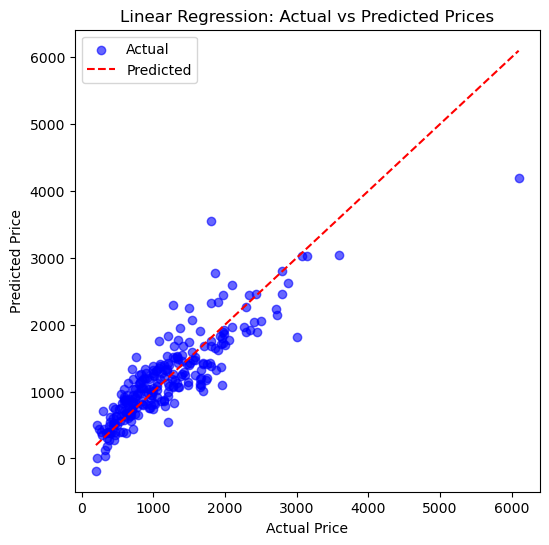

In [62]:
# visualize the results to compare actual vs predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label = 'Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Predicted')  
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.legend(loc = 'upper left')
plt.show()

### Observations
- The blue dots (actual values) are closely aligned with the dashed red line, indicating good performance. The linear regression model does reasonably well in predicting prices.
- The blue dots are more spread out, particularly as the prices increase. This could suggest that linear regression may not capture the underlying complexity of the data as well as Random Forest does, leading to slightly higher errors in predictions.

In [63]:
# Initialize the model
rf_model = RandomForestRegressor(random_state = 42, n_estimators = 100)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

# Print metrics
print("Random Forest Regressor:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))


Random Forest Regressor:
MAE: 181.7471
RMSE: 271.5014
R²: 0.8515


- The Random Forest model has a lower average error(MAE), performing better than Linear Regression.
- The RMSE is smaller than Linear Regression, indicating that Random Forest is better at minimizing larger prediction errors.
- Random Forest explains 85.15% of the variance, which is a significant improvement over Linear Regression, indicating a stronger fit to the data.

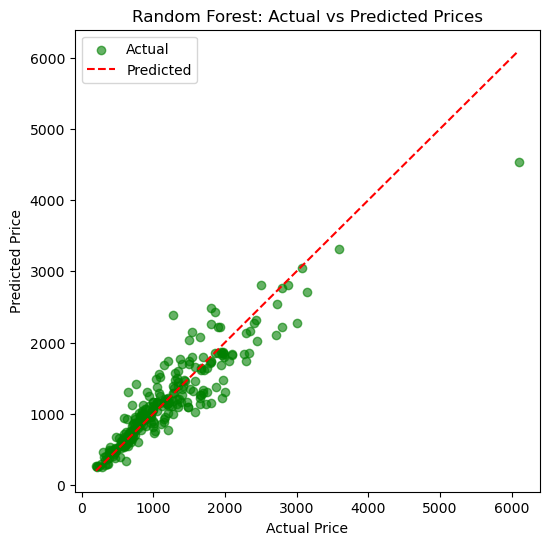

In [64]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, color='green', alpha=0.6, label = 'Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Predicted')  
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.legend()
plt.show()

### Observations
- The green dots (actual values) are closely aligned with the red dashed line (predicted values), suggesting that the Random Forest model is capturing the data well. The points are scattered tightly around the line, meaning the predictions are generally accurate.
- There are some outliers on the higher end (around the 5000-6000 price range), indicating that while the model performs well for most data points, it struggles with extreme values.
- Given that Random Forest is a non-linear model, the scatter around the predicted line is expected. However, the fit still appears solid for the majority of the data.
- Random Forest outperforms Linear Regression in all metrics: lower MAE, RMSE, and a higher R² value.
- Linear Regression has a higher error rate and explains less of the variance, suggesting it's less suited for this particular dataset.
- Random Forest handles non-linearity and outliers more effectively, leading to more accurate predictions overall.

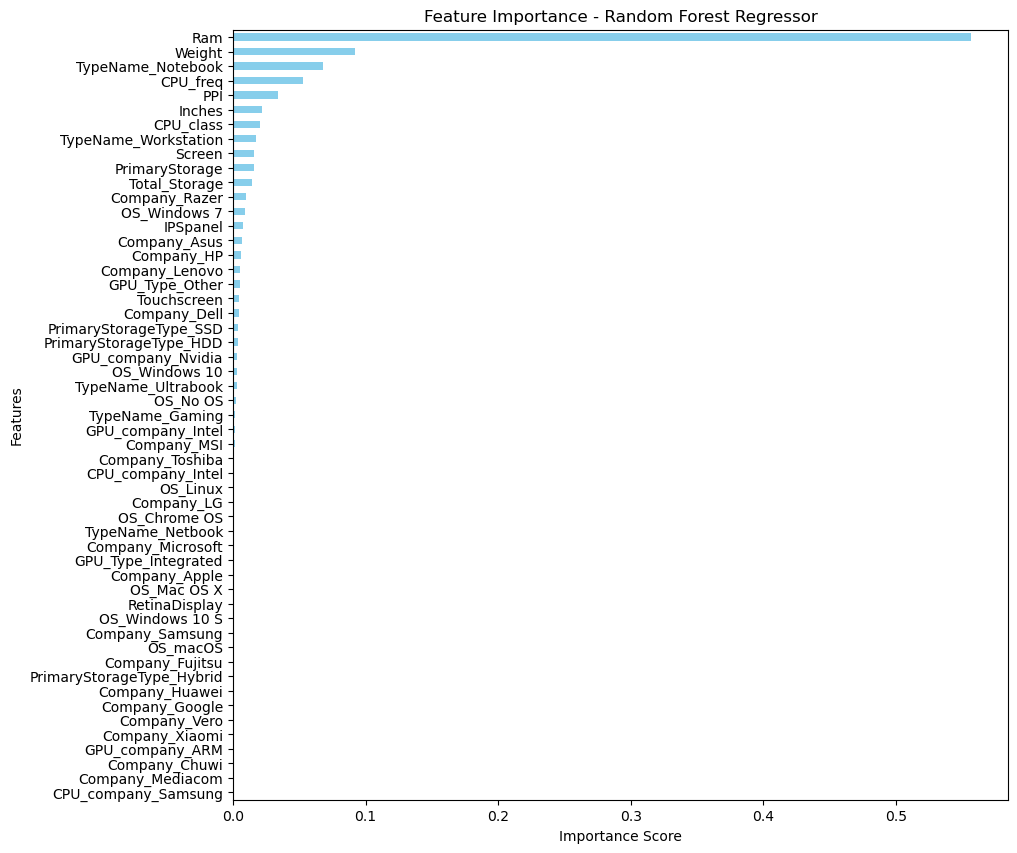

In [65]:
# Get feature importance from the trained Random Forest model
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort features by importance
feature_importance = feature_importance.sort_values(ascending = True)

# Plot for better visualization
plt.figure(figsize = (10,10))
feature_importance.plot(kind='barh', color='skyblue')
plt.title("Feature Importance - Random Forest Regressor")
plt.ylabel("Features")
plt.xlabel("Importance Score")
plt.show()


- RAM is by far the most important feature influencing laptop prices, significantly outweighing all other variables.
- Weight, TypeName_Notebook, CPU frequency, and PPI also contribute meaningfully, though their impact is much smaller compared to RAM.
- Features like Inches, CPU class, Screen size, Primary Storage, and Total Storage show moderate importance.
- Brand and OS features play only a minor role in price prediction.